# Stochastic Neural Network
#### Different data, different input format than nn.ipynb

We fit a stochastic neural network that maps two inputs, x1 and x2, to output y

The surrogate is a single-hidden-layer `tanh` network

$$ \hat{\mathbf{y}}(x) = W_2 \sigma(W_1 x + b_1) + b_2 $$

whose final-layer weights obey stochastic priors so we can sample functions.

In [1]:
# Import statements
import matplotlib.pyplot as plt
import torch
import numpy as np
import pickle  # for loading from the pickle file

from pypolymix.parameter_groups import IIDGaussianGroup, DeterministicGroup
from pypolymix.surrogate_models import NeuralNetwork
from pypolymix import StochasticModel

In [2]:
# Set random seed
_ = torch.manual_seed(2048)

### Data Loading and Manipulation
The data is stored in a .pickle file in the current directory. After the pickle file is parsed into an object, the object has

- two inputs: obj['data']['x1'] and obj['data']['x2'], which are both Numpy Arrays
- one output: obj['data']['U']['u'], which is a Numpy Array

In [3]:
with open("Data_example_2D.pickle", "rb") as f:
    obj = pickle.load(f)
obj

{'data': {'x1': array([-0.33975469, -0.06907272, -0.17979853, ..., 35.05144388,
         34.67361962, 35.09477575], shape=(175000,)),
  'x2': array([ 0.19491692, -0.1022902 ,  0.29936746, ..., 49.58621192,
         49.79646296, 49.78121542], shape=(175000,)),
  'x': array([[-0.33975469,  0.19491692],
         [-0.06907272, -0.1022902 ],
         [-0.17979853,  0.29936746],
         ...,
         [35.05144388, 49.58621192],
         [34.67361962, 49.79646296],
         [35.09477575, 49.78121542]], shape=(175000, 2)),
  'U': {'u': array([  1.19902006,  -0.6639478 ,   1.88374065, ..., 120.45177259,
          119.17548508, 121.95499968], shape=(175000,))}}}

Data manipulation to get 2-D input and output tensors

In [4]:
def dict_to_tensors(obj):
    '''
    Input schema
    {
        'data': {
            'var1': np.array([values...]),  # Input variable 1
            'var2': np.array([values...]),  # Input variable 2
            ...
            'U': {
                'output1': np.array([values...]),  # Output variable 1
                'output2': np.array([values...]),  # Output variable 2
                ...
            }
        }
    }

    Note that all input and output keys map to numpy arrays of the same length
    
    Returns 2-D float tensor of input vars, 2-D float tensor of output vars
    '''
    output_dict = obj["data"]["U"]
    # k != x is a workaround
    # since Data_example_2D.pickle has 'x' already pre-built
    input_dict = {k: v for k, v in obj["data"].items() if k != "U" and k != 'x'}

    # conversion to numpy.ndarray done because of a warning that
    # creating a tensor from a list of numpy.ndarrays is extremely slow
    X_np = np.column_stack(list(input_dict.values())).astype(np.float32)
    Y_np = np.column_stack(list(output_dict.values())).astype(np.float32)
    return torch.from_numpy(X_np), torch.from_numpy(Y_np)

In [5]:
X, Y = dict_to_tensors(obj)
X

tensor([[-0.3398,  0.1949],
        [-0.0691, -0.1023],
        [-0.1798,  0.2994],
        ...,
        [35.0514, 49.5862],
        [34.6736, 49.7965],
        [35.0948, 49.7812]])

Here's a visualization of each individual input's relation to the output.

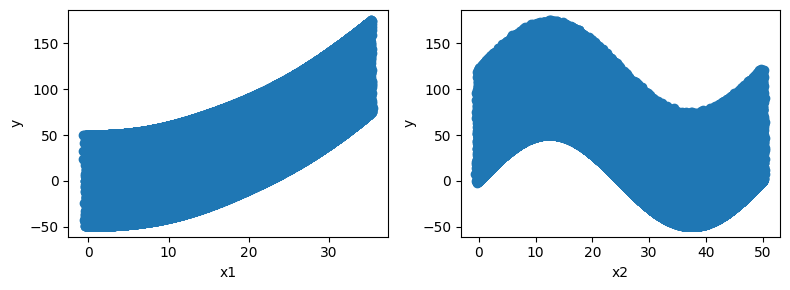

In [6]:
# Plot data
_, axes = plt.subplots(1, 2, figsize=(8, 3))
for j, (x, ax) in enumerate(zip(X.T, axes.flatten())):
    ax.scatter(x, Y)
    ax.set_xlabel(f"x{j + 1}")
    ax.set_ylabel(f"y")
plt.tight_layout()

### Model Configuration
We configure a width-16, depth-1 tanh network and print how many trainable parameters it contains so we have a sense of model capacity.

In [7]:
# Create a surrogate model
width = 16
depth = 1
# find num_inputs and num_outputs from the given data
num_inputs = X.shape[1]
num_outputs = Y.shape[1]
surrogate_model = NeuralNetwork(
    num_inputs=num_inputs, num_outputs=num_outputs,
    width=width, depth=depth, activation=torch.nn.functional.tanh
)
num_params = surrogate_model.num_params()
print(f"This model has {num_params} parameters")

This model has 65 parameters


All weights/biases up through the hidden layer are treated as deterministic, while the output-layer weights and biases follow i.i.d. Gaussian priors. This split lets us capture uncertainty primarily in the mapping from hidden features to the outputs, similar to a Bayesian neural network in the "Bayesian in the last layer" configuration.

Note that the input_layer_weights is num_inputs * width because there are that many connections between the number of inputs and the first layer of the NN.

In [8]:
# Create parameter groups
parameter_groups = [  # Input layer
    DeterministicGroup("input_layer_weights", num_inputs * width),
    DeterministicGroup("input_layer_biases", width),
]
for j in range(depth - 1):
    parameter_groups += [  # Hidden layers
        DeterministicGroup(f"layer{j + 1}_weights", width * width),
        DeterministicGroup(f"layer{j + 1}_biases", width),
    ]
parameter_groups += [  # Output layer
    IIDGaussianGroup("output_weights", num_outputs * width),
    IIDGaussianGroup("output_biases", num_outputs),
]

The `StochasticModel` pairs the deterministic neural network with the grouped parameters so that sampling, log-prior penalties, and inference utilities become available.

In [9]:
# Create stochastic model
model = StochasticModel(
    surrogate_model=surrogate_model, parameter_groups=parameter_groups
)
print(f"Created stochastic model with {model.num_params()} parameters")

Created stochastic model with 65 parameters


### Model Training

We pick learning-rate and weight-decay values, set a small `weight_factor` for the distribution loss, introduce a learnable log-precision `log_tau`, and build the AdamW optimizer plus `OneCycleLR` scheduler.

In [10]:
# Training options
lr = 1e-3             # Learning rate
weight_decay = 1e-4   # Weight decay for AdamW
weight_factor = 1e-2  # Weight factor for distribution loss
num_epochs = 10000    # Number of epochs
num_samples = 100     # Number of parameter samples per epoch

# Learnable global precision
log_tau = torch.nn.Parameter(torch.tensor(0.0))  # τ = exp(log_tau)

# Optimizer: AdamW
optimizer = torch.optim.AdamW(
    list(model.parameters()) + [log_tau], lr=lr, weight_decay=weight_decay
)

# Loss
loss_fn = torch.nn.MSELoss(reduction="sum")

# Scheduler: OneCycleLR
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=10 * lr,
    total_steps=num_epochs
)

Each epoch samples 100 parameter realizations, evaluates the network, computes the precision-scaled MSE on the predictive mean, adds the distribution regularizer, and performs backpropagation followed by the optimizer/scheduler updates.

In [11]:
# Train the stochastic model
for epoch in range(num_epochs):
    optimizer.zero_grad()

    # Evaluate parameters and model
    params = model.sample_parameters(num_samples=num_samples)
    Y_hat = surrogate_model(X, params)

    # Losses
    data_loss = loss_fn(Y_hat, Y.unsqueeze(0).expand_as(Y_hat)) / num_samples
    data_loss *= torch.exp(log_tau)
    distribution_loss = model.distribution_loss()
    total_loss = data_loss + weight_factor * distribution_loss

    # Backprop + step
    total_loss.backward()
    optimizer.step()
    scheduler.step()

    # Logging
    if (epoch + 1) % 1000 == 0:
        current_lr = scheduler.get_last_lr()[0]
        print(
            f"Epoch {epoch + 1:5d} | "
            f"learning rate = {current_lr:.6f} | "
            f"data loss = {data_loss.item():.4f} | "
            f"distribution loss = {distribution_loss.item():.4f} | "
            f"total loss = {total_loss.item():.4f}"
        )

Epoch  1000 | learning rate = 0.002801 | data loss = 198351600.0000 | distribution loss = 95.4915 | total loss = 198351600.0000
Epoch  2000 | learning rate = 0.007603 | data loss = 31888254.0000 | distribution loss = 222.3730 | total loss = 31888256.0000
Epoch  3000 | learning rate = 0.010000 | data loss = 9206037.0000 | distribution loss = 355.4226 | total loss = 9206041.0000
Epoch  4000 | learning rate = 0.009504 | data loss = 4144603.7500 | distribution loss = 460.9724 | total loss = 4144608.2500
Epoch  5000 | learning rate = 0.008116 | data loss = 2204076.0000 | distribution loss = 553.9241 | total loss = 2204081.5000
Epoch  6000 | learning rate = 0.006110 | data loss = 1359524.1250 | distribution loss = 630.5663 | total loss = 1359530.3750
Epoch  7000 | learning rate = 0.003885 | data loss = 893168.8125 | distribution loss = 688.7338 | total loss = 893175.6875
Epoch  8000 | learning rate = 0.001881 | data loss = 679451.8750 | distribution loss = 730.8304 | total loss = 679459.1875

### Model Evaluation
After training we switch to eval mode. We create a 2-D grid of evenly spaced test points, and ask the stochastic model for 1000 posterior samples so we can estimate predictive uncertainty.

In [12]:
GRID_SIZE = 200
x1_min, x1_max = X[:, 0].min(), X[:, 0].max()
x2_min, x2_max = X[:, 1].min(), X[:, 1].max()

x1_test = torch.linspace(x1_min, x1_max, GRID_SIZE)
x2_test = torch.linspace(x2_min, x2_max, GRID_SIZE)

X1_grid, X2_grid = torch.meshgrid(x1_test, x2_test, indexing="ij")
X_test = torch.stack([X1_grid.reshape(-1), X2_grid.reshape(-1)], dim=1)

model.eval()
# no gradient because this is prediction and not training
with torch.no_grad():
    Y_test = model(X_test, num_samples=1000)
Y_test.shape

torch.Size([1000, 40000, 1])

### Plotting Results
For each output dimension we show the mean prediction and the central 90% credible interval obtained from the samples.

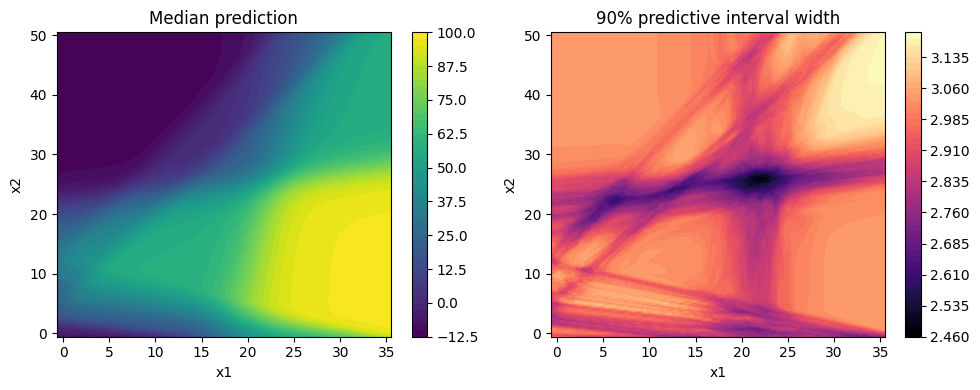

In [13]:
# Y_test: shape [1000, 40000, 1]
y_samples = Y_test.squeeze(-1)  # [1000, 40000]

# median and central 90% prediction
q = torch.quantile(y_samples, torch.tensor([0.05, 0.5, 0.95]), dim=0)

y_lower = q[0].reshape(GRID_SIZE, GRID_SIZE)
y_median = q[1].reshape(GRID_SIZE, GRID_SIZE)
y_upper = q[2].reshape(GRID_SIZE, GRID_SIZE)

# Reshape X_test back into 2-D grids
X1_grid = X_test[:, 0].reshape(GRID_SIZE, GRID_SIZE)
X2_grid = X_test[:, 1].reshape(GRID_SIZE, GRID_SIZE)

# Uncertainty width: 95th percentile - 5th percentile
y_uncertainty = y_upper - y_lower

# Convert to NumPy arrays for matplotlib
X1_grid_np = X1_grid.detach().numpy()
X2_grid_np = X2_grid.detach().numpy()
y_median_np = y_median.detach().numpy()
y_uncertainty_np = y_uncertainty.detach().numpy()

# Plot prediction
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Median prediction
c0 = axes[0].contourf(
    X1_grid_np,
    X2_grid_np,
    y_median_np,
    levels=50,
    cmap="viridis"
)
fig.colorbar(c0, ax=axes[0])
axes[0].set_title("Median prediction")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")

# Predictive uncertainty
c1 = axes[1].contourf(
    X1_grid_np,
    X2_grid_np,
    y_uncertainty_np,
    levels=50,
    cmap="magma"
)
fig.colorbar(c1, ax=axes[1])
axes[1].set_title("90% predictive interval width")
axes[1].set_xlabel("x1")
axes[1].set_ylabel("x2")

plt.tight_layout()
plt.show()

# TODO: export the results of the ML model and its predictions to the desired output format

**From GUI documentation**

Export and Save Options
Saving the Surrogate Model & Training Results

The outputs of the Surrogate Training Module are automatically saved in ../sm_wordir/GUIDemo when training has successfully completed, and will be stored in the form of two Python pickle files:

`SM.pickle` – a Python‑pickled dictionary that stores the trained surrogate model. The dictionary has the following keys:

input_maps: scikit‑learn‑style scaler objects used to map the raw input variables to the scaled space.

output_maps: scaler objects for the output variables.

roi: a dictionary describing the region‑of‑interest for each variable.

mesh: the most important entry; it holds the nodal coordinates and the connectivity matrix defining the interpolation mesh.

mesh_specs: specifications used to build the mesh (element counts, extrusion settings, etc.).

nodes_mapped: boolean indicating if nodal values are scaled or in original physical units.

nodal_values: the calibrated nodal values (physical units of output response) obtained after training.

constrained: a boolean indicating whether output constraints were applied.

data_file: path to the original data file that was used for training.


`train_output.pickle`, which contains the predictions at the trained inference points.

======================

Both files are necessary and must live in the same directory. `train_output.pickle` is the one to select in the GUI.

## Creating the output files

#### train_output.pickle
A dictionary with the following keys
- "U" -> a dictionary of the output values (Y)
- "Usm" -> a dictionary of the **s**urrogate **m**odel's predicted output values
- "unmapped" -> a dictionary of the inputs (X)

Note that the GUI assumes U and Usm are in a scaled output space.
"If your external code only has physical-space outputs, you have two options:
Store physical outputs in U and Usm, but provide an identity transformer in SM["output_maps"].
Actually map/scale the outputs before saving them, and provide the matching inverse transform."

# Problems
- **The GUI crashes when I try to run experiments with 2-D data.** It still plots the data well though.
    - Fix: follow these steps
        - Load the 2-D pickle file
        - Plot x1 and x2 vs u
        - press "preview mesh"
        - press "run training"
- I don't know the expected format of train_output.pickle
    - Fix: I read through the GUI code to find it. I used my unpickling code to unpickle an example train_output.pickle to confirm.
- SM.pickle has a lot of fields that I don't know how to get from Pypolymix's neural network output.
    - Fix: none yet. I'll have to read through pypolymix's code.
- I don't know what SM.pickle's keys mean
    - Fix: Maybe unpickling a SM.pickle example will help

In [14]:
def to_numpy_1d(x):
    """
    Convert torch tensor or array-like to flat NumPy array.
    """
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().numpy()
    return np.asarray(x).reshape(-1)

x1_physical = to_numpy_1d(X[:, 0])
x1_physical

array([-0.3397547 , -0.06907272, -0.17979853, ..., 35.051445  ,
       34.67362   , 35.094776  ], shape=(175000,), dtype=float32)

In [15]:
import os
import pickle
import numpy as np
import torch

from sklearn.preprocessing import FunctionTransformer

In [16]:
def to_numpy_1d(x):
    """
    Convert torch tensor or array-like to flat NumPy array.
    """
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().numpy()
    return np.asarray(x).reshape(-1)


def predict_median_in_batches(model, X_tensor, num_samples=200, batch_size=20000):
    """
    Evaluate the stochastic model in batches and return the median prediction.

    Returns
    -------
    y_pred : np.ndarray, shape (N,)
    """
    model.eval()
    preds = []

    with torch.no_grad():
        for start in range(0, X_tensor.shape[0], batch_size):
            stop = start + batch_size
            X_batch = X_tensor[start:stop]

            # Shape: [num_samples, batch_size, num_outputs]
            Y_batch_samples = model(X_batch, num_samples=num_samples)

            # For one output, squeeze to [num_samples, batch_size]
            Y_batch_samples = Y_batch_samples.squeeze(-1)

            # Median over stochastic samples
            Y_batch_median = torch.quantile(Y_batch_samples, 0.5, dim=0)

            preds.append(Y_batch_median.detach().cpu())

    return torch.cat(preds, dim=0).numpy()


def make_triangular_grid_connectivity(grid_size):
    """
    Build triangular connectivity for a structured GRID_SIZE x GRID_SIZE grid.

    Assumes node ordering matches:
        node_id = i * GRID_SIZE + j

    Returns
    -------
    conn : np.ndarray, shape (2 * (grid_size - 1)^2, 3)
    """
    conn = []

    for i in range(grid_size - 1):
        for j in range(grid_size - 1):
            n00 = i * grid_size + j
            n01 = i * grid_size + (j + 1)
            n10 = (i + 1) * grid_size + j
            n11 = (i + 1) * grid_size + (j + 1)

            # Split each rectangular cell into two triangles
            conn.append([n00, n10, n11])
            conn.append([n00, n11, n01])

    return np.asarray(conn, dtype=np.int64)

In [17]:
output_dir = "my_training_results"
os.makedirs(output_dir, exist_ok=True)

input_names = ["x1", "x2"]
output_name = "u"

# -----------------------------
# Training/evaluation arrays
# -----------------------------

# Physical input arrays from training data
x1_physical = to_numpy_1d(X[:, 0])
x2_physical = to_numpy_1d(X[:, 1])

# Physical reference output from training data
u_reference_physical = to_numpy_1d(Y[:, 0])

# Surrogate prediction at the original training points
u_surrogate_physical = predict_median_in_batches(
    model,
    X,
    num_samples=200,
    batch_size=20000
)

training_result = {
    "U": {
        output_name: u_reference_physical,
    },
    "Usm": {
        output_name: u_surrogate_physical,
    },
    "unmapped": {
        "x1": x1_physical,
        "x2": x2_physical,
    }
}

# -----------------------------
# Mesh/nodal values for SM.pickle
# -----------------------------

# Use your existing prediction grid as the GUI mesh.
# X_test has shape [GRID_SIZE * GRID_SIZE, 2]
mesh_nodes = X_test.detach().cpu().numpy()

# Triangular connectivity for the structured grid
mesh_conn = make_triangular_grid_connectivity(GRID_SIZE)

# Use your median grid prediction as nodal values.
# If y_median already exists from your plotting cell:
u_nodal_physical = y_median.reshape(-1).detach().cpu().numpy()

# -----------------------------
# Identity maps
# -----------------------------
# Since we are saving physical values directly, inverse_transform should do nothing.
identity_map = FunctionTransformer(
    func=None,
    inverse_func=None,
    validate=False
)

SM = {
    "mesh": {
        "nodes": mesh_nodes,
        "conn": mesh_conn,
        # Do not include "M" unless you really have a meaningful n_nodes x n_nodes matrix.
    },
    "input_maps": {
        "x1": identity_map,
        "x2": identity_map,
    },
    "output_maps": {
        output_name: identity_map,
    },
    "nodal_values": {
        output_name: u_nodal_physical,
    },

    # Extra fields that may be useful to the GUI or future debugging
    "nodes_mapped": False,
    "constrained": False,
    "data_file": "Data_example_2D.pickle",
    "roi": {
        "x1": [float(np.min(x1_physical)), float(np.max(x1_physical))],
        "x2": [float(np.min(x2_physical)), float(np.max(x2_physical))],
        output_name: [
            float(np.min(u_reference_physical)),
            float(np.max(u_reference_physical))
        ],
    },
    "mesh_specs": {
        "element_numbers": {
            "x1": GRID_SIZE - 1,
            "x2": GRID_SIZE - 1,
        }
    },
}

# -----------------------------
# Save pickle files
# -----------------------------

training_result_path = os.path.join(output_dir, "training_result.pickle")
sm_path = os.path.join(output_dir, "SM.pickle")

with open(training_result_path, "wb") as f:
    pickle.dump(training_result, f)

with open(sm_path, "wb") as f:
    pickle.dump(SM, f)

print(f"Saved: {training_result_path}")
print(f"Saved: {sm_path}")

Saved: my_training_results/training_result.pickle
Saved: my_training_results/SM.pickle
